In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyMLaux import plot_2d_prediction
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsRegressor

# New: GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV

housing = fetch_california_housing()
X, y = housing.data, housing.target
print(housing["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Train samples: 13209
Validation samples: 3303
Test samples: 4128


In [3]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_val_scaled = sc.transform(X_val)
X_test_scaled = sc.transform(X_test)

In [4]:
base_model = KNeighborsRegressor(weights="uniform")

param_grid = {
    "n_neighbors" : [x for x in range(1,51,2)],
    "weights" : ["uniform", "distance"]
}

# scoring is either a string (https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) or a callable function of type f(y_true, y_pred) = error
# Mean squared error = neg_mean_squared_error --> negative because it optimizes the model by maximizing the error score (we usually minimize MSE)
# TODO: Fill out GCV parameters
gcv = GridSearchCV(base_model, param_grid, n_jobs = -1, scoring = "neg_mean_squared_error", cv = 3)
gcv.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [5]:
# TODO: Showcase best hyperparameters
gcv.best_params_

{'n_neighbors': 13, 'weights': 'distance'}

In [6]:
# TODO: Showcase CV statistics
gcv.cv_results_

{'mean_fit_time': array([0.02416531, 0.02494136, 0.0247256 , 0.0221204 , 0.02167821,
        0.02221592, 0.02128466, 0.02237471, 0.02436964, 0.02200111,
        0.0224812 , 0.02174942, 0.02277629, 0.01984239, 0.01997598,
        0.02014661, 0.01693916, 0.01697469, 0.01842332, 0.01511502,
        0.01547138, 0.0138061 , 0.01332815, 0.0133156 , 0.01393048,
        0.01310889, 0.01345754, 0.01385927, 0.0144031 , 0.01433325,
        0.01357563, 0.01332903, 0.01324066, 0.0142831 , 0.01378576,
        0.0134964 , 0.0132854 , 0.01437616, 0.01315959, 0.01345412,
        0.01850112, 0.013791  , 0.01475747, 0.01383368, 0.01399469,
        0.01312407, 0.01528557, 0.01375214, 0.01303252, 0.01345189]),
 'std_fit_time': array([1.28301132e-03, 2.42519766e-03, 2.55149967e-03, 1.83071070e-03,
        1.26116430e-03, 9.86177605e-04, 6.37580565e-04, 1.65086460e-03,
        2.16449821e-03, 1.82668350e-03, 2.86288440e-03, 7.68086642e-04,
        2.99596021e-03, 6.13702853e-04, 4.51288913e-04, 1.18691143e-0

In [7]:
# TODO: Print mean results per configuration (k)
gcv.cv_results_["mean_test_score"]

array([-0.64808543, -0.64808543, -0.45607086, -0.4532757 , -0.42992852,
       -0.42463249, -0.42028984, -0.4142701 , -0.41540927, -0.40913221,
       -0.41463809, -0.40771081, -0.41457752, -0.4073758 , -0.41564202,
       -0.40814971, -0.41667487, -0.4089293 , -0.41962959, -0.41144296,
       -0.42146896, -0.41301314, -0.42317679, -0.41450762, -0.42498416,
       -0.41603291, -0.4266769 , -0.41757695, -0.42824957, -0.41905904,
       -0.43009081, -0.42073305, -0.43231264, -0.42266325, -0.4335691 ,
       -0.42383961, -0.43469906, -0.42488184, -0.43641416, -0.42643168,
       -0.43742855, -0.42741832, -0.4384952 , -0.42847947, -0.43976693,
       -0.42966935, -0.4412145 , -0.43100175, -0.44293932, -0.4325377 ])

In [8]:
# TODO: Print best score (best model average performance over all CV folds)
gcv.best_score_

np.float64(-0.40737580185794947)

In [10]:
# if refit=True in GridSearchCV
model = gcv.best_estimator_

# if refit=False, we have to do it ourselves - refit does this in the background!
model = KNeighborsRegressor(**gcv.best_params_)
model = base_model.fit(X_train_scaled, y_train)

In [11]:
print("MSE Train:", mean_squared_error(y_train, model.predict(X_train_scaled)))
print("MSE Validation:", mean_squared_error(y_val, model.predict(X_val_scaled)))
print("MSE Test:", mean_squared_error(y_test, model.predict(X_test_scaled)))

MSE Train: 0.2644834446845381
MSE Validation: 0.42915367713850067
MSE Test: 0.42436620923449025


In [12]:
print("R2 Train:", r2_score(y_train, model.predict(X_train_scaled)))
print("R2 Validation:", r2_score(y_val, model.predict(X_val_scaled)))
print("R2 Test:", r2_score(y_test, model.predict(X_test_scaled)))

R2 Train: 0.8005173531032199
R2 Validation: 0.6890163413178818
R2 Test: 0.6761574315492238


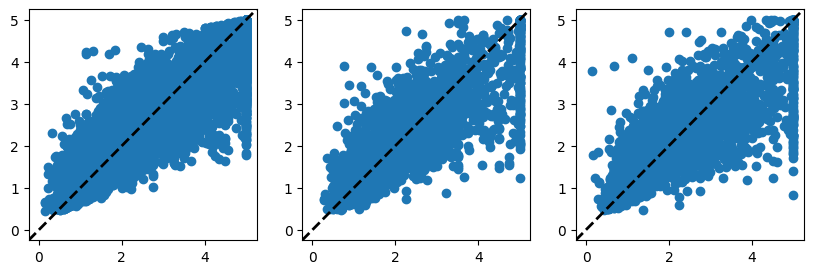

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
ax[0].scatter(y_train, model.predict(X_train_scaled))
ax[1].scatter(y_val, model.predict(X_val_scaled))
ax[2].scatter(y_test, model.predict(X_test_scaled))

ax[0].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[1].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[2].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)

# Pipeline Approach

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.impute import KNNImputer

# TODO: Create named pipeline using tuples --> ("name", PipelineStep())
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("impute", KNNImputer()),
    ("model" , KNeighborsRegressor()) 
])

param_grid = {
    "model__n_neighbors": [x for x in range(1,51,2)]
    
}

gcv = GridSearchCV(base_model, param_grid, cv=3, n_jobs=-1, scoring="neg_mean_squared_error")
gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

Question: The pipeline approach also carries one more, intricate, and often neglected upside - what is it? 

*(Hint: It is related to pre-processing - e.g., scaler and imputer)*

In [ ]:
# cv = 5 is default, but we can increase this. What if we set cv = len(X_train)?
# --> Each datapoint is used as validation set ONCE and rest is used for training. (LeaveOneOut CV)
# --> Really expensive!  

#gcv = GridSearchCV(base_model, param_grid=param_grid, scoring="r2", cv=LeaveOneOut())
#gcv.fit(X_train, y_train)

In [15]:
gcv.best_params_

{'model__n_neighbors': 13}

In [16]:
model = gcv.best_estimator_
print("MSE Train:", mean_squared_error(y_train, model.predict(X_train)))
print("MSE Validation:", mean_squared_error(y_val, model.predict(X_val)))
print("MSE Test:", mean_squared_error(y_test, model.predict(X_test)))

MSE Train: 0.3368023871111436
MSE Validation: 0.4202879726787168
MSE Test: 0.4100902818641381


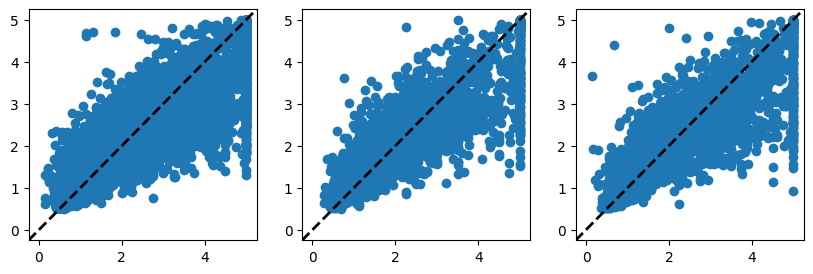

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
ax[0].scatter(y_train, model.predict(X_train))
ax[1].scatter(y_val, model.predict(X_val))
ax[2].scatter(y_test, model.predict(X_test))

ax[0].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[1].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[2].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)

In [18]:
# Alternatives that are less computationally expensive:
from sklearn.model_selection import RandomizedSearchCV

# TODO: Parameterize RandomizedSearchCV parameters (hint: what is the termination criterion?)
gcv = RandomizedSearchCV(base_model, param_grid, scoring = "neg_mean_squared_error", cv = 5, n_iter = 20)
gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__n_neighbors': [1, 3, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-

In [19]:
gcv.best_params_

{'model__n_neighbors': 9}

In [20]:
model = gcv.best_estimator_
print("MSE Train:", mean_squared_error(y_train, model.predict(X_train)))
print("MSE Validation:", mean_squared_error(y_val, model.predict(X_val)))
print("MSE Test:", mean_squared_error(y_test, model.predict(X_test)))

MSE Train: 0.31220741047300454
MSE Validation: 0.418580860437188
MSE Test: 0.4114589276033478


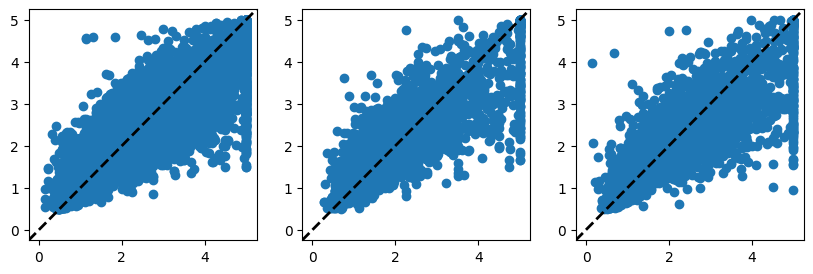

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
ax[0].scatter(y_train, model.predict(X_train))
ax[1].scatter(y_val, model.predict(X_val))
ax[2].scatter(y_test, model.predict(X_test))

ax[0].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[1].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)
ax[2].axline((0, 0), (1,1), color="k", linestyle="--", lw=2)

Not covered here, but honorable mention: 

* scikit-optimize (https://scikit-optimize.github.io/stable/) 
* hyperopt (https://hyperopt.github.io/hyperopt/) 
* optuna (https://optuna.org/)

--> Intelligently choose future parameters, based on the already evaluated ones

# Model Selection

Usually, at the end, would have several models to choose from:

* The tuned kNN model
* the tuned LogisticRegressor
* the tuned Neural Network
* etc...

But...

We already used cross-validation to get the correct hyperparameters, utilizing the train split. 

After determining the best configuration, we retrain on the entire training data, without CV splits. 

Without a dedicated third dataset, we have no way of benchmarking multiple tuned models against one another.


**This is where the validation set comes into play.**

In [22]:
models = []

In [23]:
# Train and optimize K-nearest-Neighbor Regressor and add to list
base_model = KNeighborsRegressor()
param_grid = {
    "n_neighbors": [x for x in range(1, 52, 2)],
    "weights": ["uniform", "distance"]
}
gcv = GridSearchCV(base_model, param_grid=param_grid, scoring="r2", cv=5, n_jobs=-1)
gcv.fit(X_train_scaled, y_train)

models.append(gcv.best_estimator_)

In [24]:
from sklearn.linear_model import LinearRegression

# Standard LinReg Model
base_model_2 = LinearRegression()
base_model_2.fit(X_train_scaled, y_train)
models.append(base_model_2)

In [25]:
# We can only test one model class at a time in GridSearch - now we need the dedicated validation set to compare their performances
# TODO: Evaluate all models and determine the best one.
mses = []

for model in models:
    mses.append(mean_squared_error(y_val, model.predict(X_val_scaled)))

best_index = np.argmin(mses)
best_model = models[best_index]

In [26]:
best_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",13
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
# Now, only AFTER CHOOSING the best model, we can evaluate on the test set.
# This is the only time where we are allowed to do so.
print("MSE Test:", mean_squared_error(y_test, best_model.predict(X_test)))

MSE Test: 1.333905052223078


**Final note:**

If we want to push performance of the final model, it is also common practice to pick the best model (configuration) and then retrain it one final time on the **merged train and validation set**. While this model is no longer "validated" (as in, we no longer know the "best" configuration for the new data), hyperparameters are tuned to the actual data distribution, which (hopefully) does not change drastically by adding new samples.  In any case, the variance of the final estimates should shrink, usually translating to better performance.

We don't rerun optimization, we only take the winning configuration and avoid wasting potentially important data.